<a href="https://colab.research.google.com/github/OmkarRameshJadhav108/-OpenEdHub-Open-Source-Online-Learning-Platform/blob/main/Boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("1_boston_housing.csv")

Saving 1_boston_housing.csv to 1_boston_housing.csv


In [4]:
df = pd.read_csv("1_boston_housing.csv")

df.columns = df.columns.str.replace('"', '')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print(X.shape, y.shape)

(506, 13) (506,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential([
    Dense(1, input_shape=(X_train.shape[1],), activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 618.2289 - mae: 22.9453 - val_loss: 560.4354 - val_mae: 22.1373
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 616.0237 - mae: 22.9239 - val_loss: 558.8006 - val_mae: 22.1208
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 613.8250 - mae: 22.9017 - val_loss: 557.2940 - val_mae: 22.1037
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 611.7475 - mae: 22.8819 - val_loss: 555.7120 - val_mae: 22.0875
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 609.6364 - mae: 22.8603 - val_loss: 554.2299 - val_mae: 22.0712
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 607.6041 - mae: 22.8371 - val_loss: 552.8712 - val_mae: 22.0545
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 605.5916 - mae: 22.8134 - val_loss: 551.4711 - val_mae: 22.0379
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 603.6954 - mae: 22.7942 - val_loss: 550.0296 - val_mae: 22.0218
Epoch 9/100
21/

In [10]:
loss, mae = model.evaluate(X_test, y_test)
print("MSE:", loss)
print("MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 451.0876 - mae: 20.3325
MSE: 451.087646484375
MAE: 20.332521438598633


In [11]:
y_pred = model.predict(X_test)

for i in range(5):
    print(y_test.iloc[i], "→", y_pred[i][0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
23.6 → 4.653241
32.4 → 9.55084
13.6 → -4.4778047
22.8 → 5.3397884
16.1 → -3.9176254


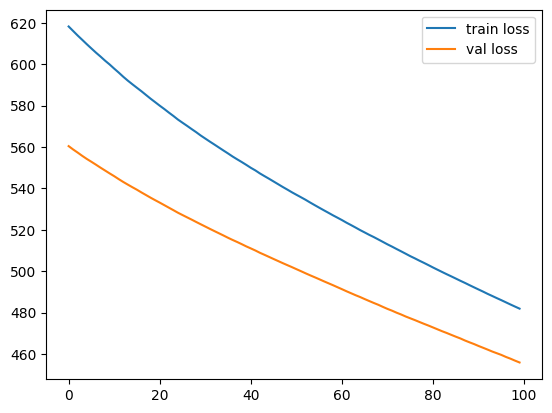

In [12]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()